## О наборе данных
Этот классический набор данных содержит цены и другие характеристики почти 54 000 бриллиантов. Это отличный набор данных для начинающих, которые учатся работать с анализом и визуализацией данных.

## Описание признаков датасета
| Признак   | Описание |
|-----------|----------|
| carat     | Вес бриллианта в каратах |
| cut       | Качество огранки |
| color     | Цвет бриллианта |
| clarity   | Прозрачность - показатель чистоты алмаза |
| depth     | Общая глубина в процентах |
| table     | Ширина вершины ромба относительно самой широкой точки |
| price     | Стоимость, указана в долларах США |
| x         | Длина в мм |
| y         | Ширина в мм |
| z         | Глубина в мм |


In [4]:
import pandas as pd
import numpy as np
import math
from plots import get_statistic, get_hist_plots, get_box_plots, get_corr_matrix, get_scatter_plot, get_violin_plot
import matplotlib.pyplot as plt
from matplotlib.backends.backend_pdf import PdfPages
import seaborn as sns

In [2]:
# Прочитаем данные из файла
df = pd.read_csv('diamonds.csv')
df.drop(columns=['Unnamed: 0'], inplace=True)

In [4]:
# Выведем первые пять строк на экран
df.head(5)

,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75


## Информация по датасету
    При вызове функции get_statistic() получаем инфо по нашему датасету. Видим, что:
- В датасете 53940 строки, 10 колонок
- Пропусков нет
- Имеется три типа данных в колонках: float64, int64 и str
- Кол-во уникальных значений по каждому столбцу: видим, что минимальное кол-во уникальных значений 5, значит константные признаки отсутствуют
- Можно увидеть моду и ее частоту по каждой из колонок
- По цифровым колонкам можно увидеть ряд статистик: среднее, мин, макс, 25/75 перцентили, межквартильное расстояние, выбросы:
  - с помощью мин и макс можно оценить адекватность значений признаков. Например, вес алмаза не должен быть отрицательным 
  - также видим, что в данных присутствуют выбросы
- в датасете присутствуют дубли

In [5]:
df_info = get_statistic(df)
print('Количество дубликатов по строкам: ', df.duplicated().sum())
print('')
df_info

Количество дубликатов по строкам:  146



,Заполненные значения,Пропуски,"Доля пропусков, %",Dtypes,Кол-во уникальных значений,Мода,Кол-во значений моды,average,min,max,25-ый перцентиль,75-ый перцентиль,Межквартильное расстояние,Выбросы (bottom),Выбросы (top)
carat,53940,0,0.0,float64,273,0.3,2604,0.79794,0.2,5.01,0.4,1.04,0.64,-,выше 2.0
cut,53940,0,0.0,str,5,Ideal,21551,-,-,-,-,-,-,-,-
color,53940,0,0.0,str,7,G,11292,-,-,-,-,-,-,-,-
clarity,53940,0,0.0,str,8,SI1,13065,-,-,-,-,-,-,-,-
depth,53940,0,0.0,float64,184,62.0,2239,61.749405,43.0,79.0,61.0,62.5,1.5,ниже 58.75,выше 64.75
table,53940,0,0.0,float64,127,56.0,9881,57.457184,43.0,95.0,56.0,59.0,3.0,ниже 51.5,выше 63.5
price,53940,0,0.0,int64,11602,605,132,3932.799722,326.0,18823.0,950.0,5324.25,4374.25,-,выше 11885.625
x,53940,0,0.0,float64,554,4.37,448,5.731157,0.0,10.74,4.71,6.54,1.83,ниже 1.9649999999999999,выше 9.285
y,53940,0,0.0,float64,552,4.34,437,5.734526,0.0,58.9,4.72,6.54,1.82,ниже 1.9899999999999993,выше 9.27
z,53940,0,0.0,float64,375,2.7,767,3.538734,0.0,31.8,2.91,4.04,1.13,ниже 1.2150000000000003,выше 5.734999999999999


## Графики гистограмм
Гистограммы были построены для первичного анализа распределений признаков датасета. Это необходимо для:

1.	Понимания формы распределения признаков (симметричность, скошенность).
2.	Выявления выбросов и аномальных значений.
3.	Определения диапазонов значений признаков.
4.	Оценки необходимости преобразований (например логарифмирование).
5.	Проверки наличия редких значений, которые могут влиять на обучение модели.
Таким образом, гистограммы позволяют понять структуру данных до построения моделей и корректно подготовить признаки к обучению.

Числовые признаки:
- depth: распределение близко к нормальному, основная масса бриллиантов имеет глубину от 57,5 до 67,5.
- table: распределение близко к нормальному, основная масса бриллиантов имеет table от 50,5 до 60,5.
- остальные признаки имеют распределение менее похожее на нормальное
- price: распределение сильно скошено вправо — присутствуют клиенты с очень большими балансами. Возможна необходимость лог-преобразования.

Категориальные признаки:
- Распределения категорий неравномерны: некоторые значения встречаются значительно чаще других.

Целевая переменная:
- price: распределение сильно скошено вправо сто присуще финансовым показателям присутствуют экземпляры с высокими ценами.

Итог\
Построение гистограмм позволило выявить форму распределений признаков, наличие выбросов и дисбаланс категорий. Это является важным этапом EDA и помогает принять решения о дальнейшей предобработке данных и выборе моделей машинного обучения.


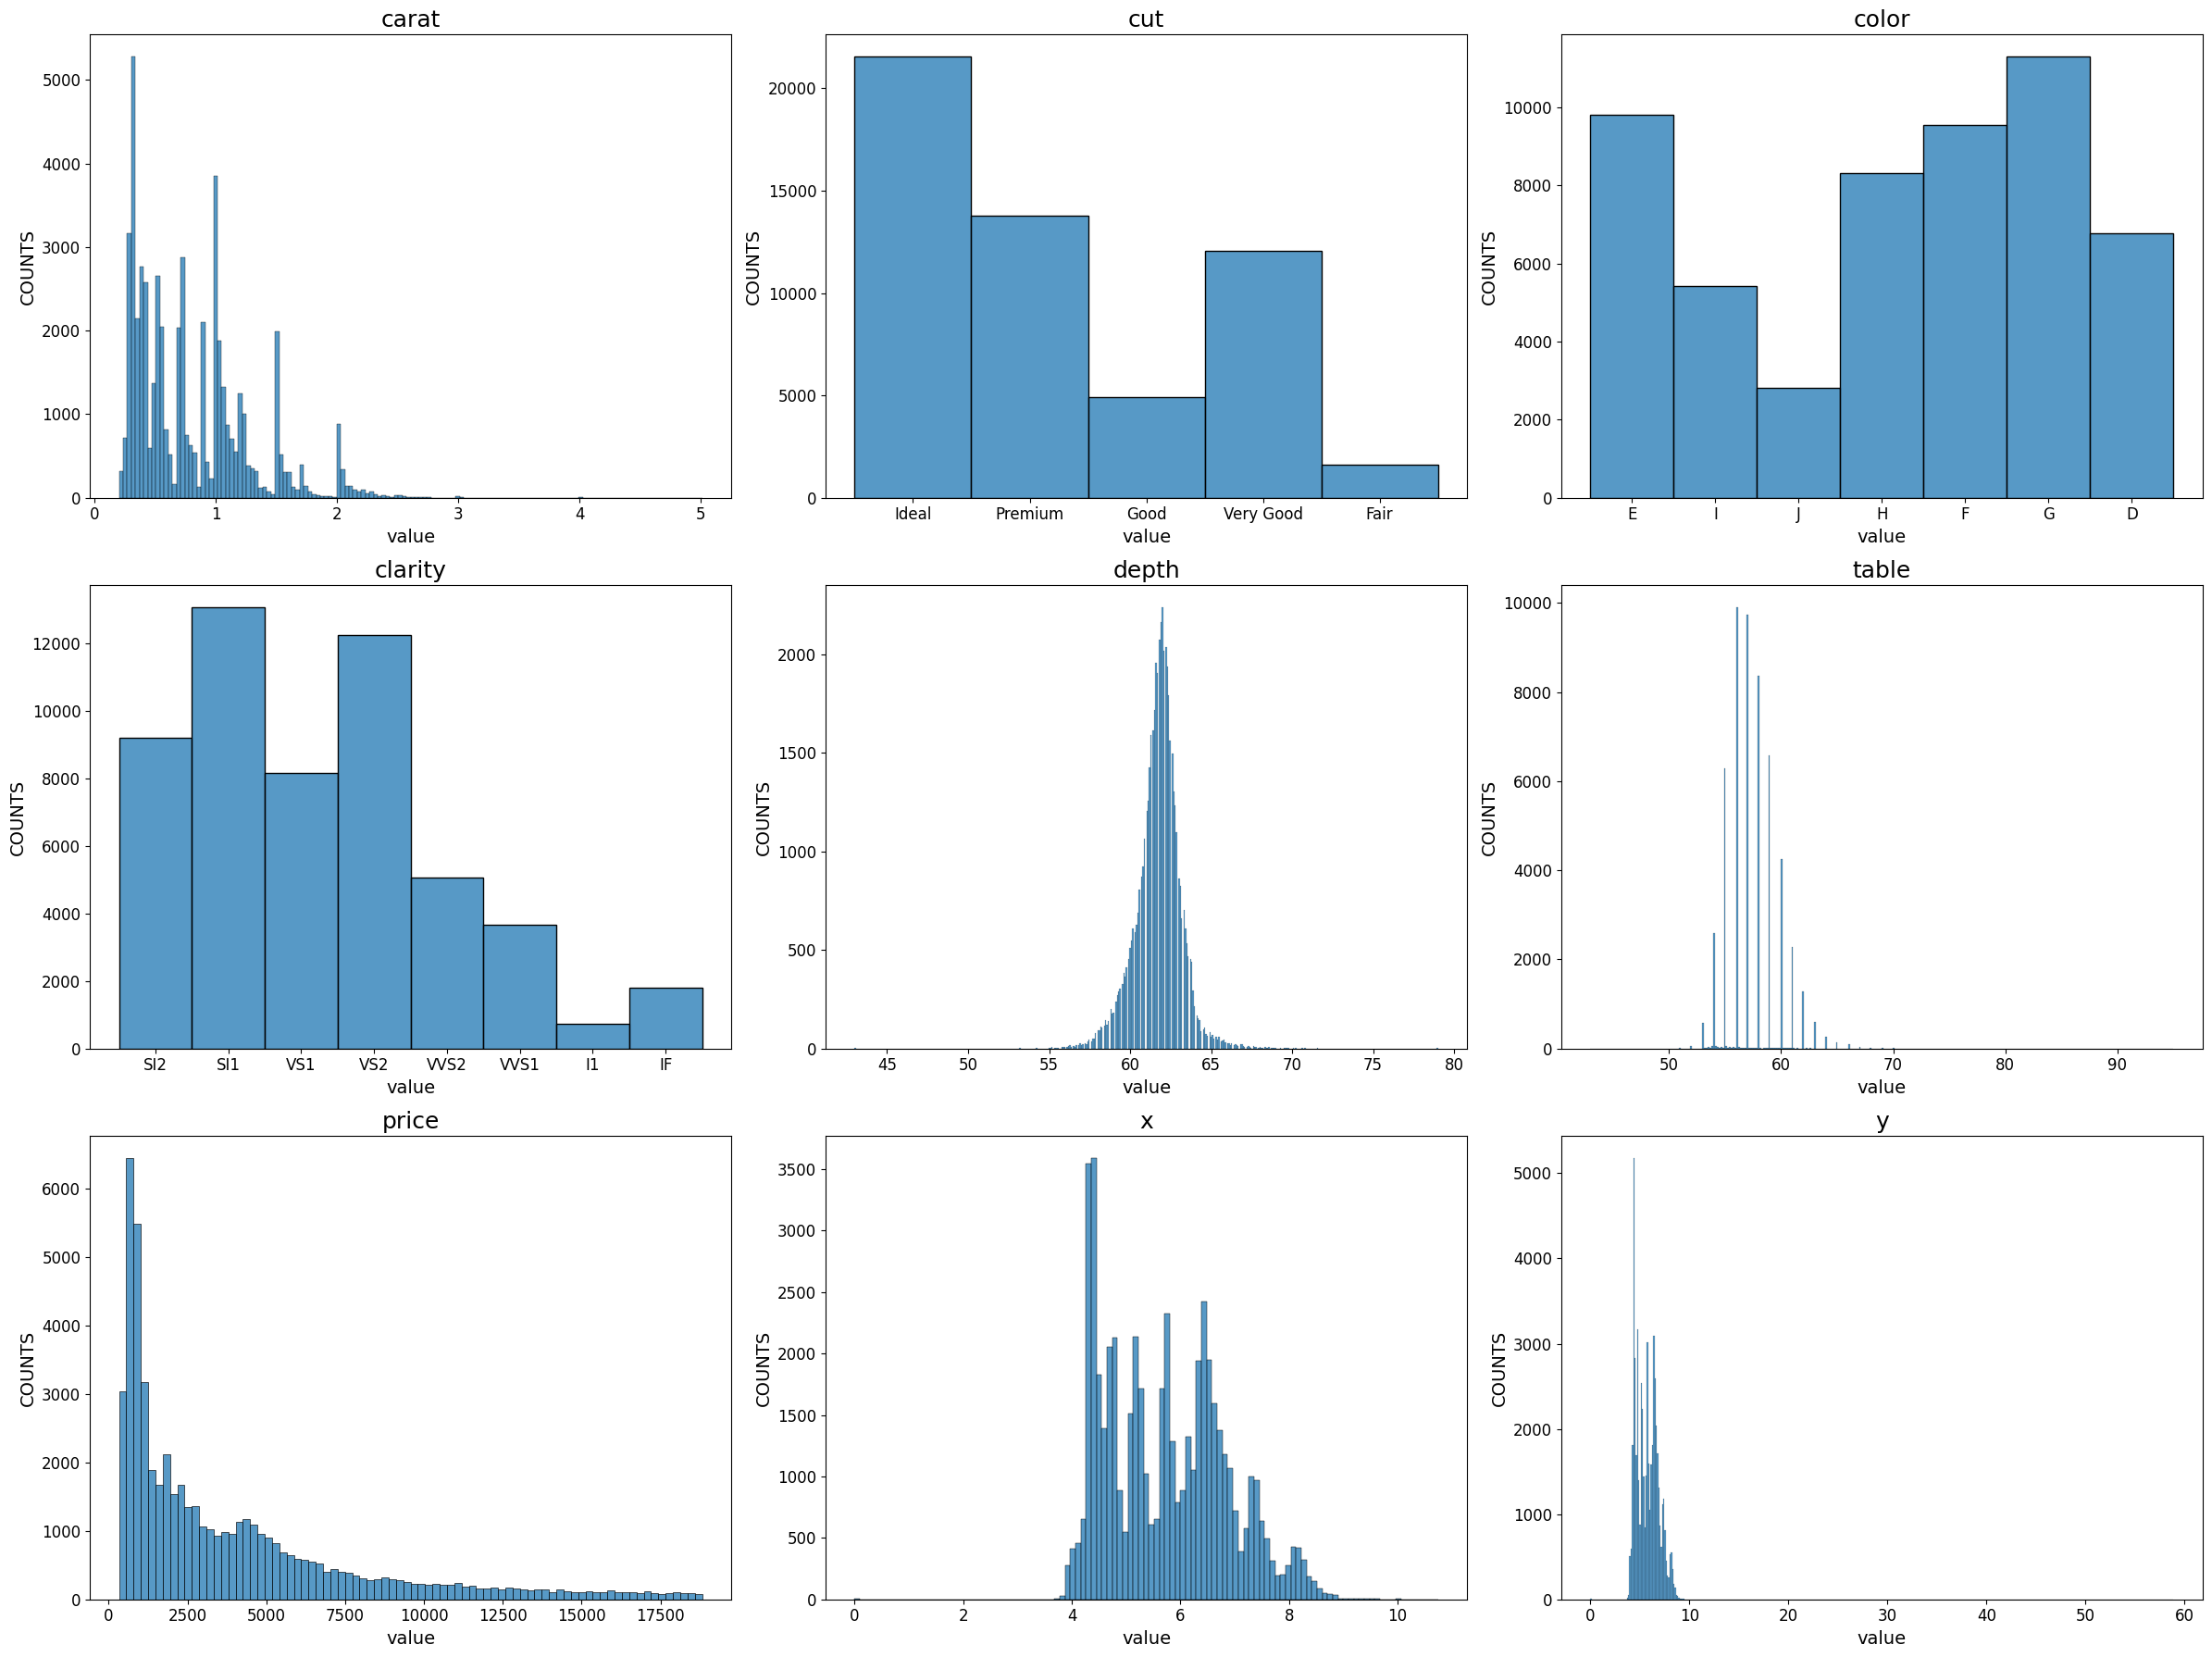

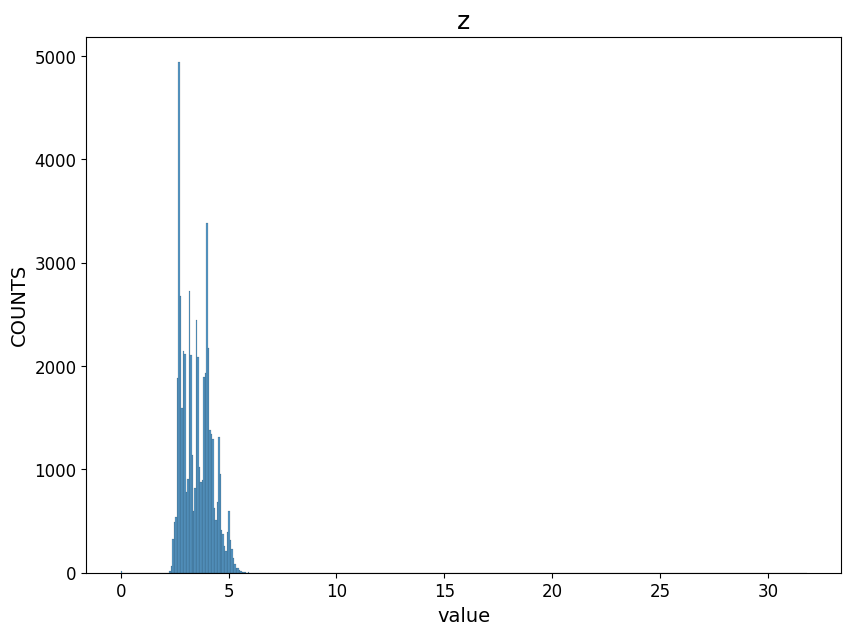

In [12]:
get_hist_plots(df)

## Графики "ящик с усами" (boxplot)


Boxplot (ящики с усами) были построены для анализа распределения числовых признаков.
Данный тип графика позволяет:

1.	Оценить центральные тенденции (медиану) признаков.
2.	Проанализировать разброс значений (межквартильный размах).
3.	Выявить выбросы и экстремальные значения.



Boxplot показал наличие выбросов во всех признаках, а также в целевой переменной.
Для некоторых признаков наблюдается сильная правосторонняя асимметрия (длинный верхний хвост).




Итог

Построение boxplot позволило визуально сравнить распределения числовых, выявить выбросы и оценить потенциальную информативность признаков для задачи регрессии.

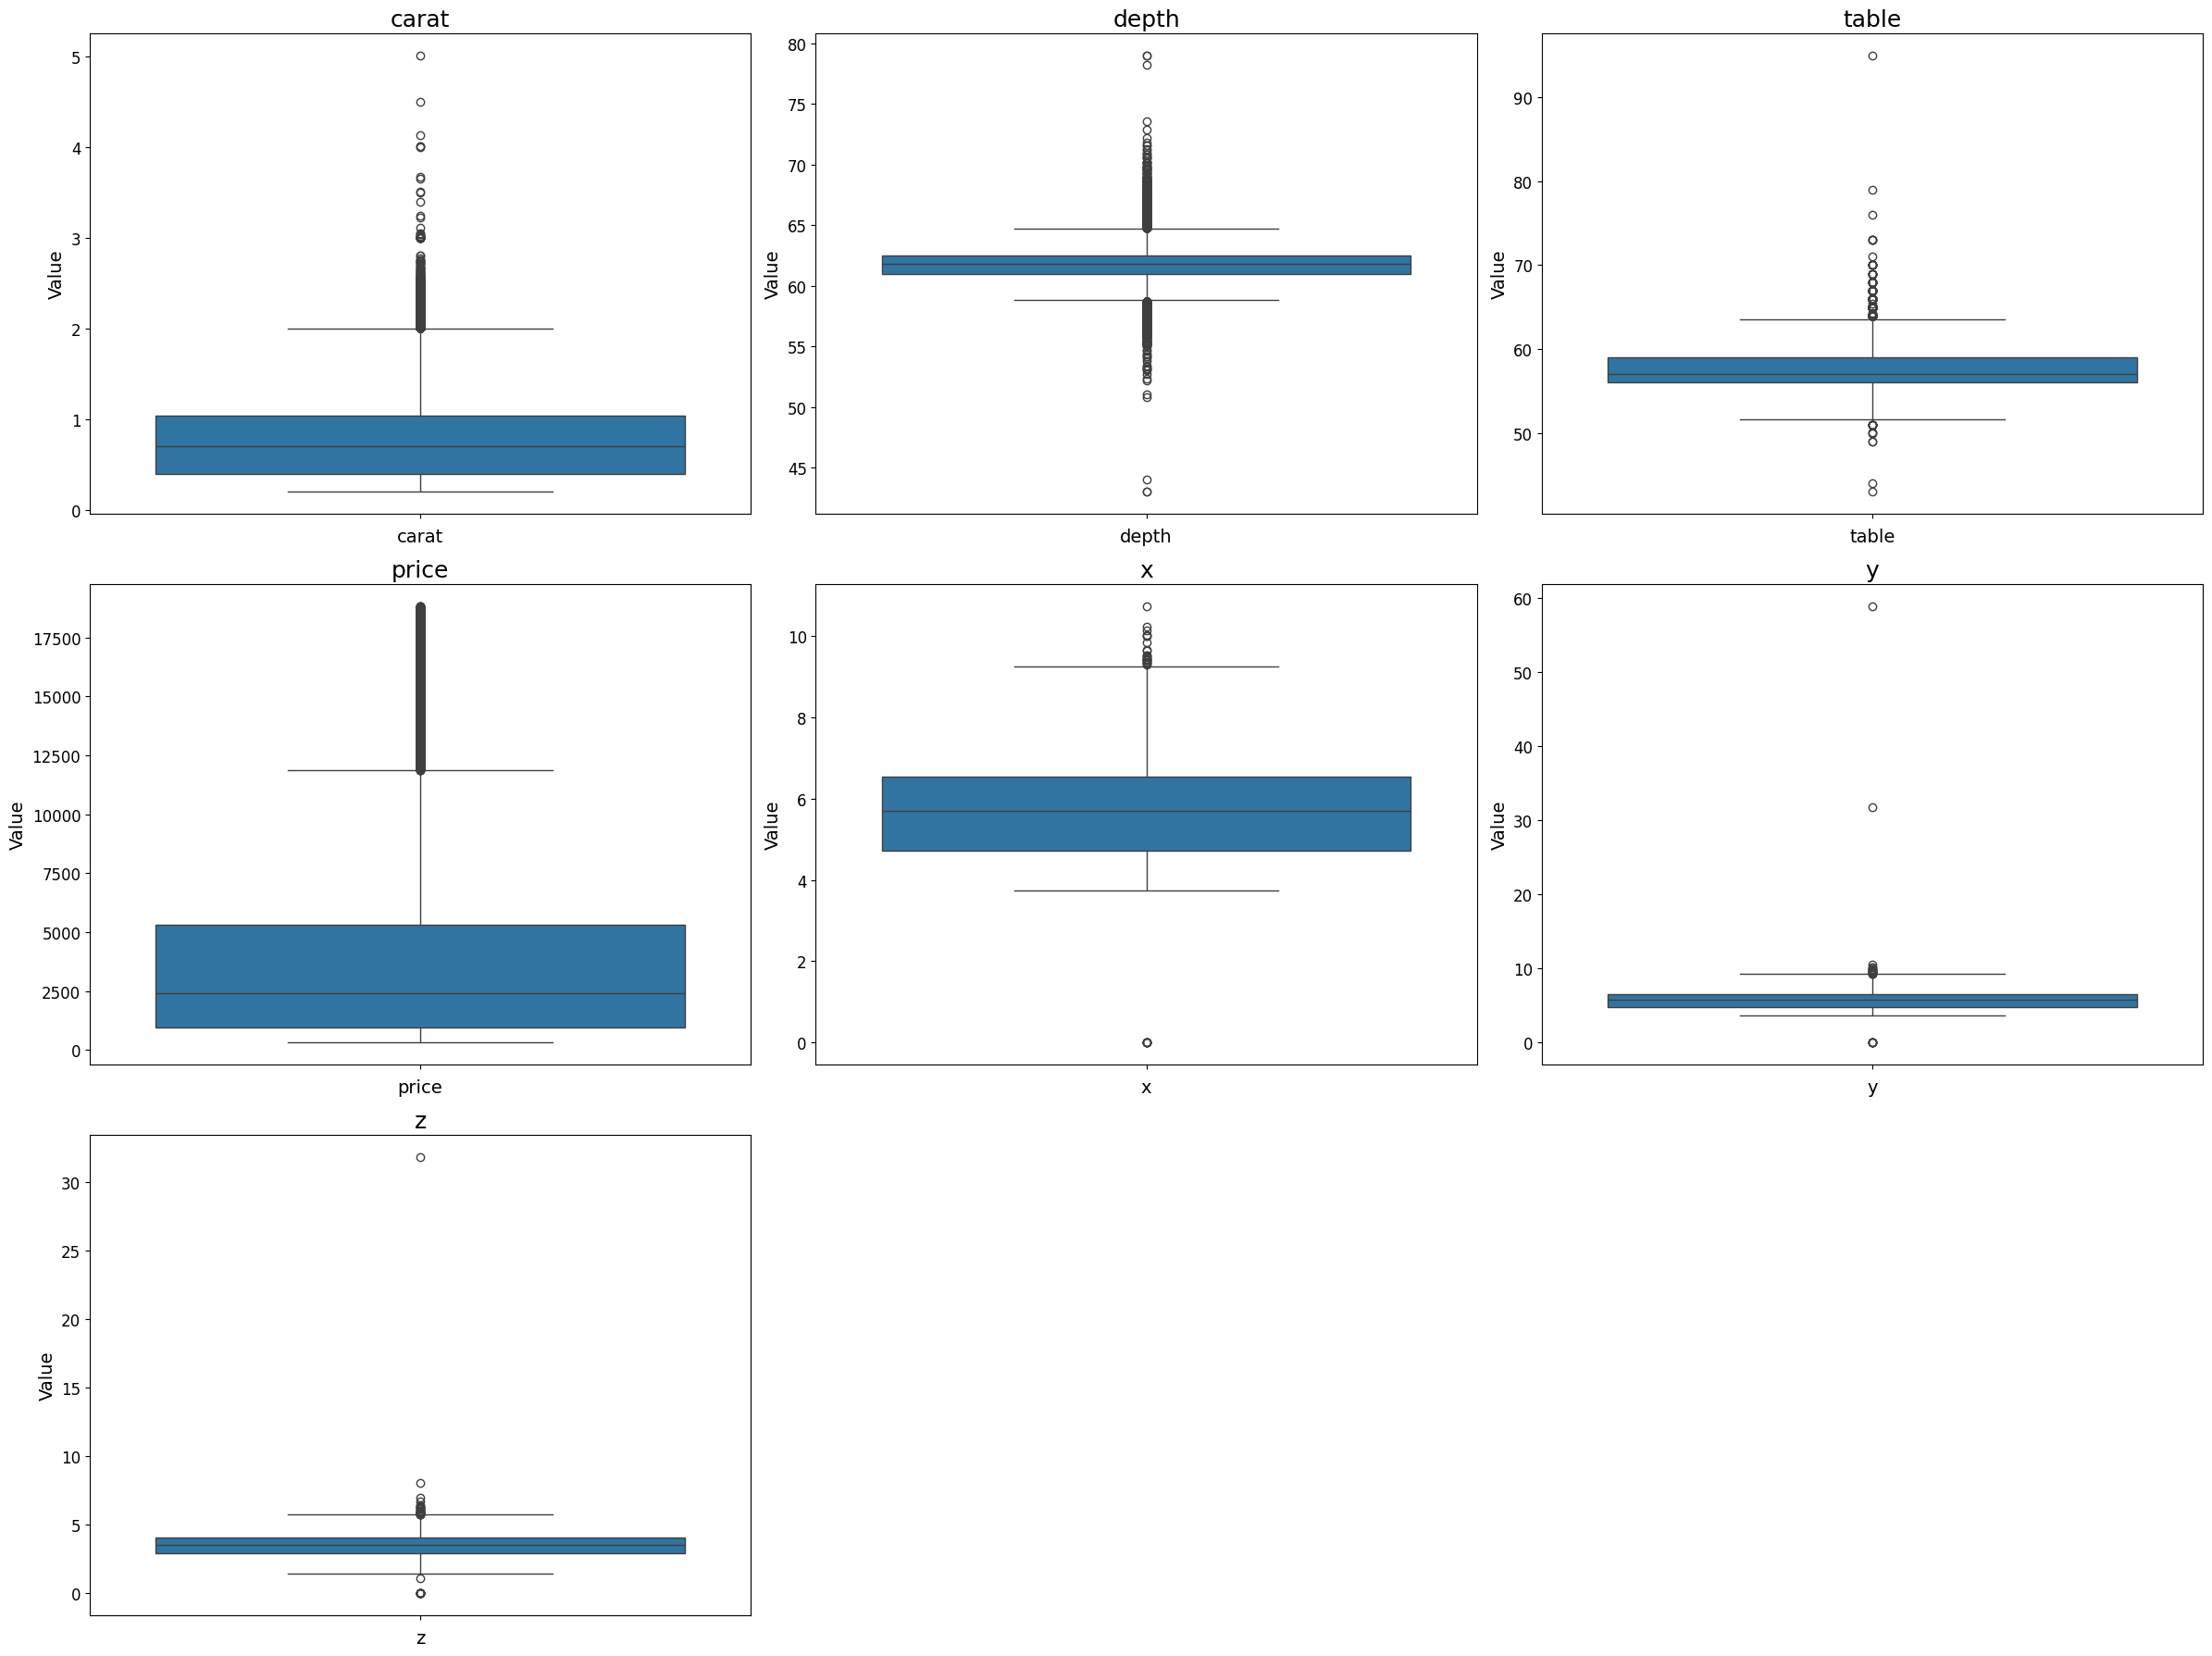

In [13]:
get_box_plots(df)

## Матрица корреляции

Матрица корреляции показывает силу и направление линейной связи между переменнными
Диапазон значений от -1 до 1. 

1 - сильная прямая связь (признаки растут вместе)

-1 - сильная обратная связь (один признак растет другой падает)

0 - взаимосвязи нет

По матрице можно сделать вывод, что мультиколлинеарность в наших признаках присутствует. Видим сильнейшую прямую линейную зависимость между признаками carat, x, y, z.

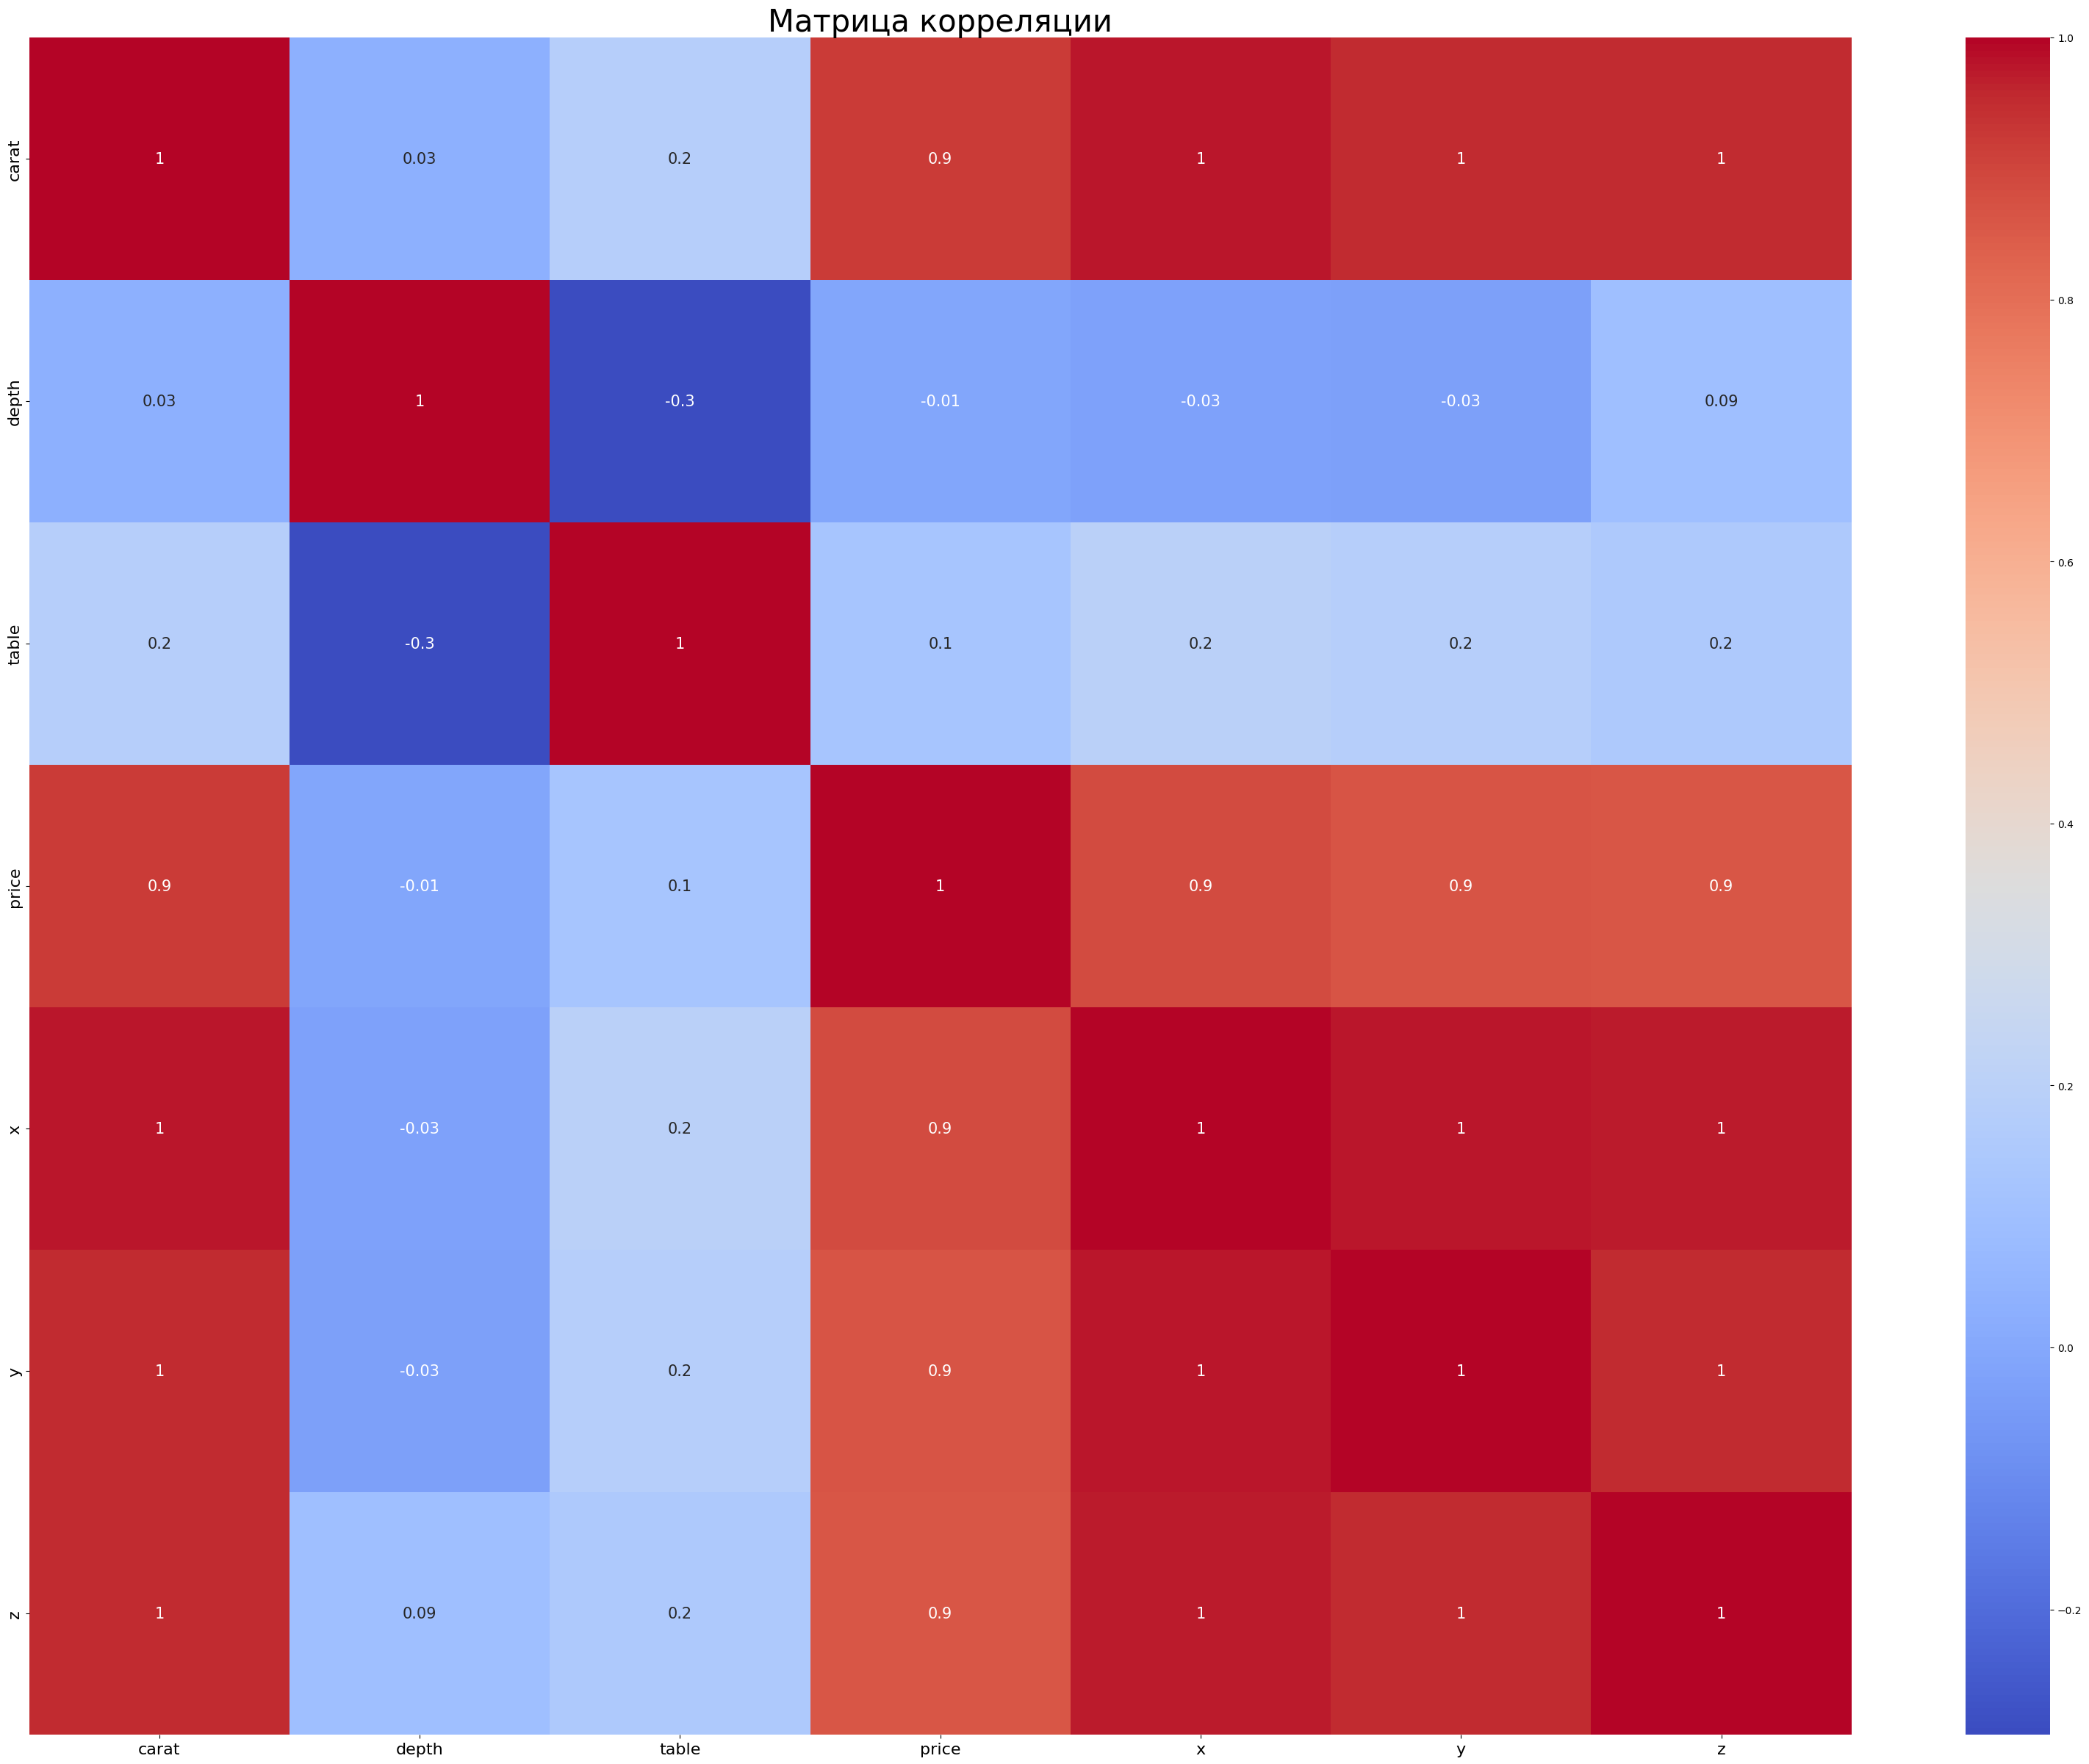

In [14]:
get_corr_matrix(df)

## Графики scatterplots


Графики scatterplots зависимсоть целевой переменной от числовых признаков.

Данный тип визуализации позволяет:

1.	Выявить форму зависимости.
2.	Наличие выбросов и аномалий.


Итог

Визуальный анализ показывает, что хоршим предиктором должен выступить признак carat. Признаки x,y,z также информативны, но между ними сильная корреляция. Признаки depth и table оказывают меньшее влияение на целевую переменную.

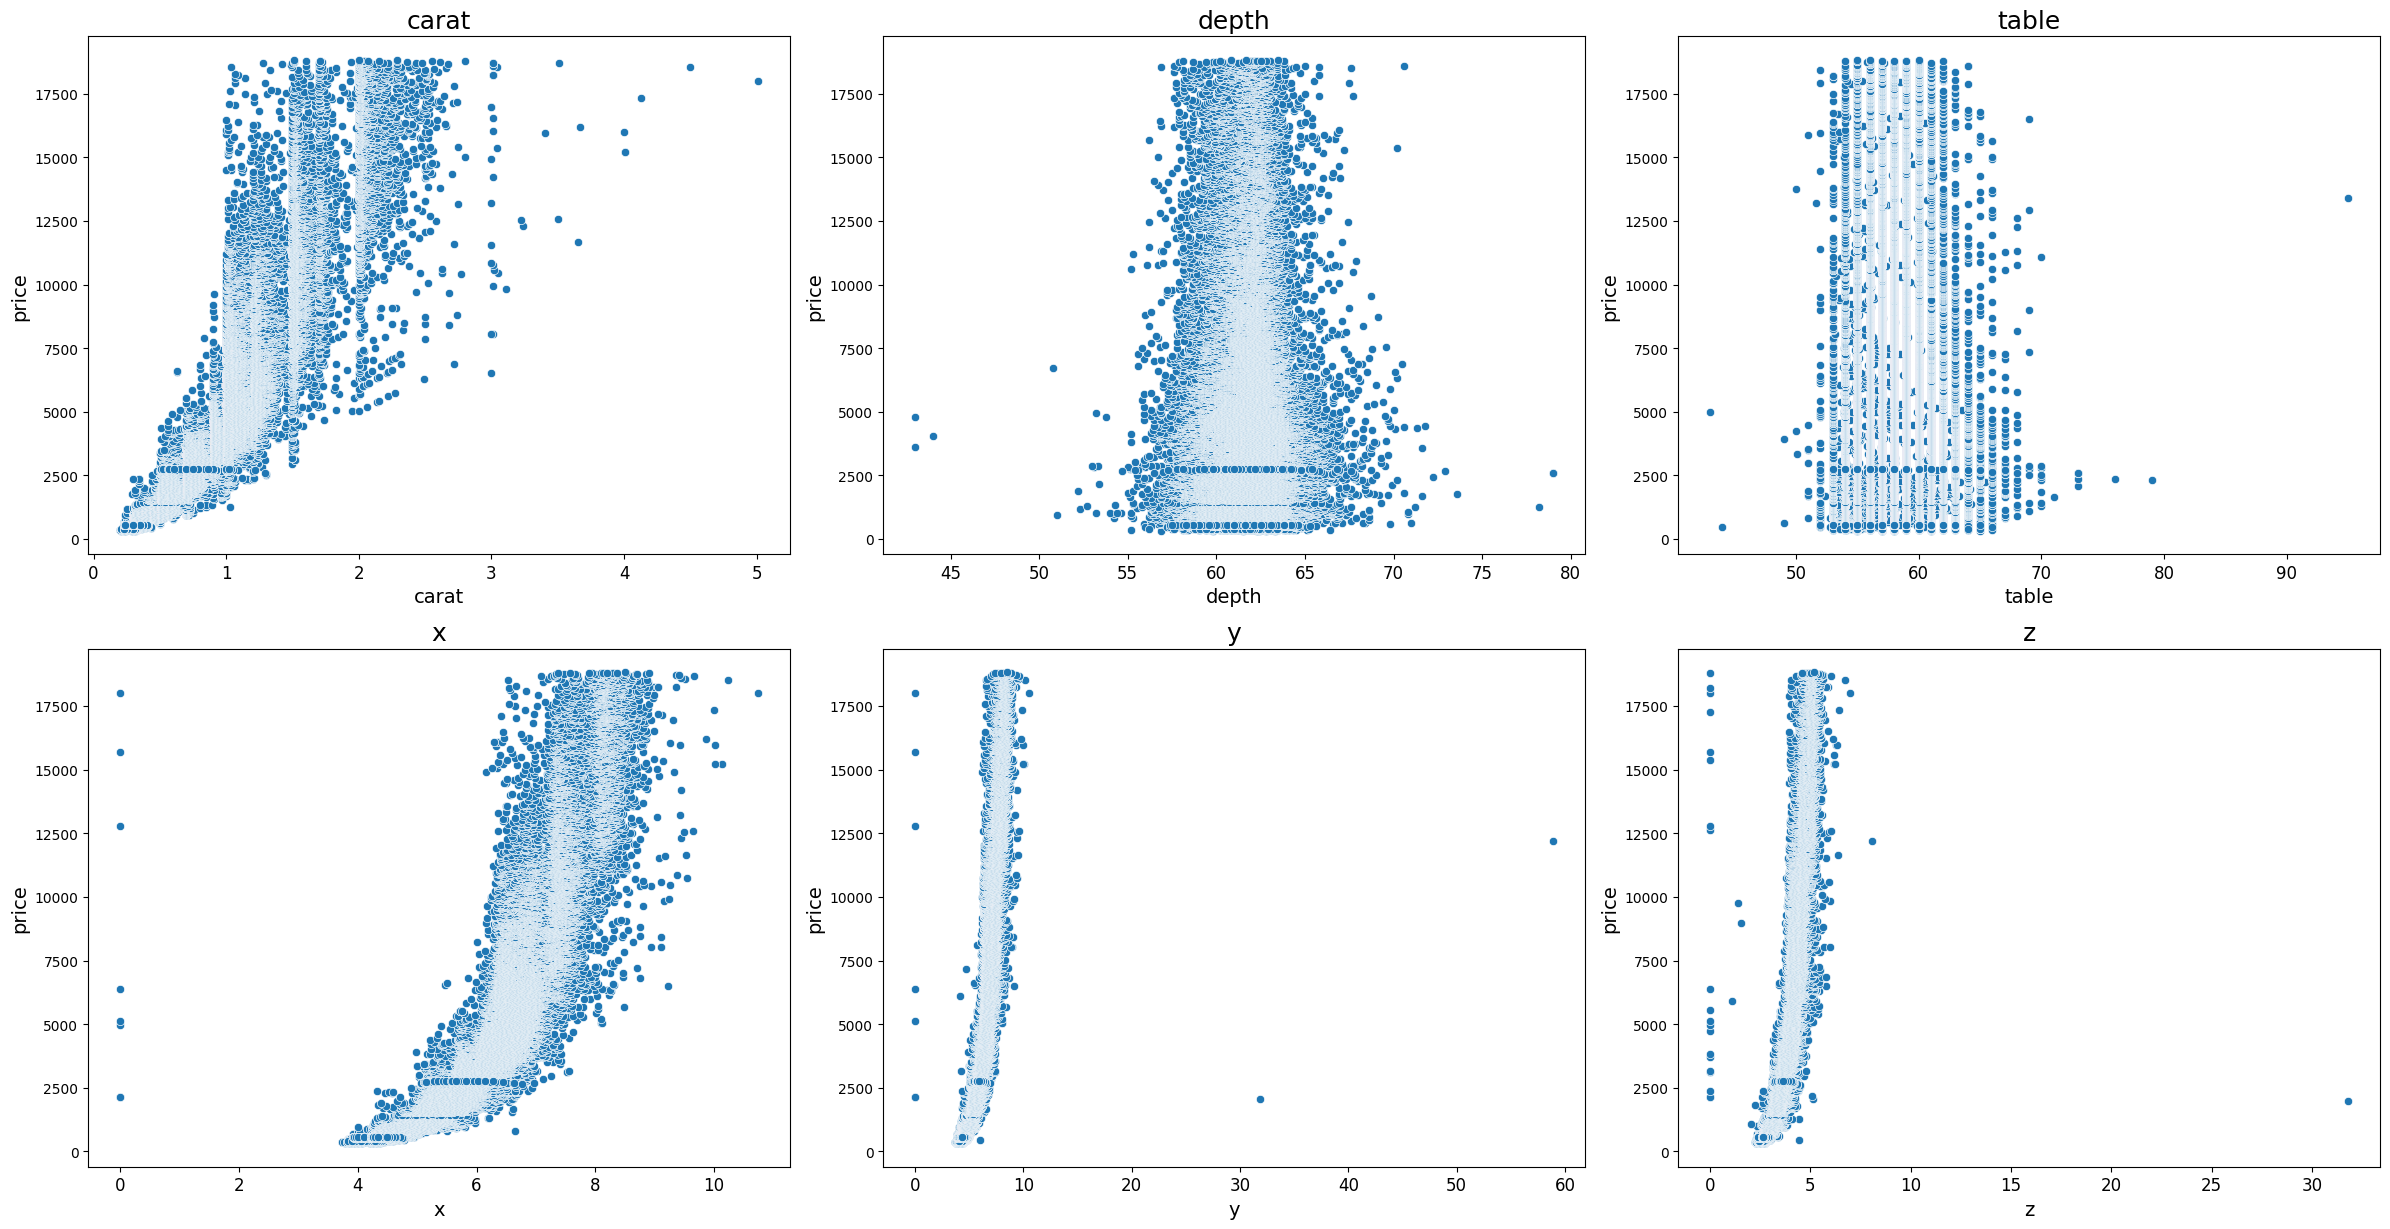

In [3]:
get_scatter_plot(df)

## Графики violinplots

Violin-графики отображают распределение цен (`price`) внутри категорий признаков `cut`, `color` и `clarity`.  
Они позволяют оценить медиану, разброс значений, форму распределения и степень перекрытия между категориями.

**1. price ~ cut (качество огранки)**   
На графике видно, что распределения цен для разных типов огранки сильно перекрываются.  
При этом медианная цена не возрастает строго с улучшением качества огранки. Более того, категория `Fair` визуально имеет более высокую медиану и больший разброс цен, чем `Ideal` и `Premium`.

Это объясняется тем, что более дешёвая огранка часто встречается у более крупных камней (больший `carat`), которые стоят дороже, несмотря на худшее качество огранки.


Качество огранки влияет на цену, но не является определяющим фактором. Цена сильнее зависит от веса камня, поэтому категории с худшей огранкой могут иметь более высокие цены из-за большего размера бриллиантов.



**2. price ~ color (цвет)**
Распределения цен по цвету также значительно перекрываются. Чёткой монотонной зависимости (что лучший цвет → выше цена) не наблюдается.  
Некоторые промежуточные категории цвета (например, G–H–I) имеют сопоставимые или даже более высокие медианы цен по сравнению с лучшими цветами (D–E).

Это снова указывает на влияние других факторов (особенно `carat`), которые оказывают более сильное влияние на цену, чем цвет.

 
Цвет влияет на цену, но его вклад умеренный. Сам по себе признак `color` недостаточен для точного предсказания цены без учёта других характеристик.


**3. price ~ clarity (прозрачность)**   
График показывает, что распределения цен по прозрачности сильно пересекаются.  
Нет строгой тенденции роста цены при улучшении прозрачности: например, категории `SI1` и `SI2` имеют довольно высокие медианные значения, а `IF` не демонстрирует явного максимума.

Это означает, что высокая прозрачность не всегда соответствует высокой цене — более крупные камни с меньшей прозрачностью могут стоить дороже маленьких, но «идеально чистых».


Прозрачность влияет на цену, но её влияние не доминирующее. Внутри каждой категории наблюдается большой разброс цен, что подтверждает сильное влияние размера камня.



### Общие выводы
1. Все категориальные признаки (`cut`, `color`, `clarity`) оказывают влияние на цену, но их распределения сильно перекрываются.
2. Ни один из категориальных признаков не демонстрирует строгой монотонной зависимости с ценой.



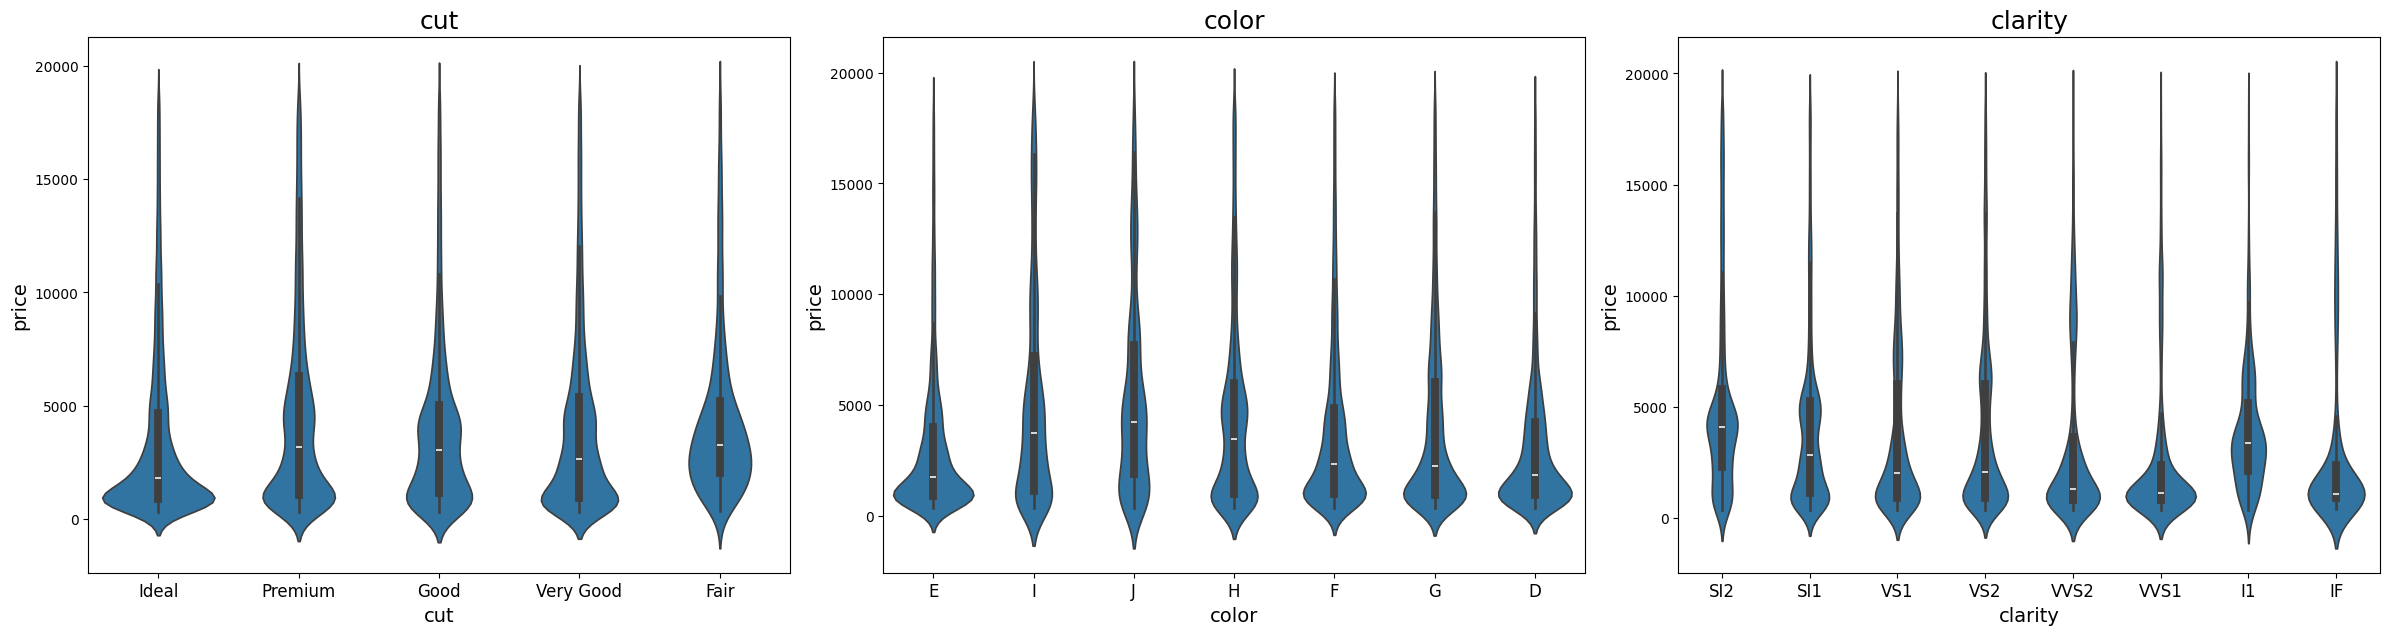

In [5]:
get_violin_plot(df)